# Survival Analysis for LGD model 

Various steps used by banks to derive the loss rate for unresolved cases 

Historical average 
Advance techniques such as Survival technique 
Cap the facilities to a certain amount based on the historical data  
conservattive approach , unresolved will have maximum loss at the time of default 


Calculate all the defaulted cases for suvival model . This has to be done for all defaults only since it is a LGD model and would consider below specific points :
1. Currently under recovery process
2. Dataset is for unsecured retail customers
3. Banks want to know about the survival probability of the defaulter customers which are not part of the LGD model
   

Steps involved :

1. Pre processing for Survival dataset
2. Understanding the dataset
3. Apply the algorithm based on the dataset description 
4. filter for obervations which have recovery vector 
5. for the max recovery time for all observations and select the time to inlcude maximum observations
6. Only non negative cash flows and recover rates are inlcuded 


In [63]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyspark
from pyspark.sql import functions as F
from functools import reduce 
#from pyspark.sql.functions import when,col,avg

# Immputing Missing data

from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from numpy.linalg import cond
from sklearn.experimental import enable_iterative_imputer  # Enable IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler

# for model application 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from lifelines import CoxPHFitter

# for visual representation , understanding data 

import matplotlib.pyplot as plt 
import seaborn as sns 
import scipy.stats as stats
from scipy.optimize import minimize,newton
from sklearn.metrics import log_loss
from sklearn.metrics import mean_squared_error, r2_score
# from skimpy import skim # package issues # version control changes needed , keep it for later post this development
# from pandas_profiling import ProfileReport # version control changes needed , keep it for later post this development 


# for model application 
import statsmodels.api as sm 

# for Newton Raphson Algorithm and #pseudo application
from scipy.optimize import fmin_bfgs,minimize


# display 
pd.set_option('display.max_rows',1000)

# for Model Calibration
from sklearn.metrics import roc_auc_score,roc_curve
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve


In [64]:
from pyspark.sql import SparkSession 
spark = SparkSession.builder.appName("survival").getOrCreate()

In [65]:
spark

In [67]:
os.chdir(r'C:\Users\prashant\Modelling\Data')

In [68]:
# default dataset 
dd = spark.read.option('header',True)\
               .option('delimiter',',')\
               .option('inferSchema',True)\
               .csv(r'C:\Users\prashant\Modelling\Data\default_data.csv')

In [69]:
# get the main loan dataset
lnd = spark.read.option('header',True)\
                .option('delimiter',',')\
                .option('inferSchema',True)\
                .csv(r'C:\Users\prashant\Modelling\Data\loan_Data.csv')

In [70]:
# get the  LGD  with account level recovery amounts 
lgd = spark.read.option('header',True)\
                .option('delimiter',',')\
                .option('inferSchema',True)\
                .csv(r'C:\Users\prashant\Modelling\Data\loss_Data.csv')

In [71]:
# to assess the shape of dataframe 

def spark_shape(self):
    return(self.count(),len(self.columns))
pyspark.sql.dataframe.DataFrame.shape = spark_shape

In [72]:
#dd = dd.filter(F.col('default_time') == 1)
dd = dd.filter(F.col('default_time') == 1)\
         .withColumn('EAD',F.col('balance_time'))

In [73]:
# check for final default cases
dd = dd.select(['id'\
                ,'first_time'\
                ,'mat_time'\
                ,'balance_time'\
                ,'LTV_time'\
                ,'interest_rate_time'\
                ,'rate_time'\
                ,'hpi_time'\
                ,'gdp_time'\
                ,'balance_orig_time'\
                ,'default_time'\
                ,'FICO_orig_time'
                ,'EAD'])

In [74]:
lgd = lgd.filter(F.col('default_time') == 1)\
         .withColumn('EAD',F.col('balance_time'))

join default dataset with loss dataset to get the recoveries , to assess the defaults for which recovery process is still underway this is needed since the recoveries dataset will be added back for Cox regression post estimation of coeffecients using ulitmate or partial recoveries dataset

Features used for final product :
check ones which are binary 
1. Mortgage/product month when defaulted
2. Original month/term 
3. LTV
4. Int rate/int_rate
5. hpi
6. gdp
7. FICO
8. ID
9. Original Balance/loan_amnt 
10. Left Balance/total_pymnt - 



From Loan dataset : 

1. Prod_m_def
2. term
3. balance_time
4. LTV(concatenate with Default data and fill the values)
5. int_rate 
6. hpi
7. gdp
8. fico(concatenate with Default data and fill the values)
9. id
10. funded_amnt
11. total_rec_prncp + total_rec_int + total_rec_late_fee + recoveries



In [75]:
# For no recovery cases LGD would be 1 , thereore post joining the LGD data and DD data need to fill the missing vaulues with 1
cols_dd = ['id','first_time','mat_time','balance_time','balance_orig_time','EAD','hpi_time','gdp_time','LTV_time','interest_rate_time','default_time']
dd_lgd_ead = dd.filter(F.col('default_time') == 1)\
               .join(lgd,dd['id'] == lgd['id'],'left')\
               .select(*[dd[col] for col in cols_dd],lgd['lgd_time'].alias('LGD'),lgd['res_time'].alias('Recovery_time'))


In [76]:
dd_lgd_ead = dd_lgd_ead.withColumnRenamed('interest_rate_time','int_rate_time')

In [77]:
# Filling up null LGD values with 1 since there are all non recovery cases therefore total loss for the bank 
lgd_fill = 1
dd_lgd_ead = dd_lgd_ead.fillna({'LGD' : lgd_fill})

In [15]:
dd_lgd_ead.where(dd_lgd_ead.LGD.isNull()).count()

0

In [50]:
dd_lgd_ead.printSchema()

root
 |-- id: integer (nullable = true)
 |-- first_time: integer (nullable = true)
 |-- mat_time: integer (nullable = true)
 |-- balance_time: double (nullable = true)
 |-- balance_orig_time: double (nullable = true)
 |-- EAD: double (nullable = true)
 |-- hpi_time: double (nullable = true)
 |-- gdp_time: double (nullable = true)
 |-- LTV_time: double (nullable = true)
 |-- int_rate_time: double (nullable = true)
 |-- default_time: integer (nullable = true)
 |-- LGD: double (nullable = false)
 |-- Recovery_time: integer (nullable = true)



## To get LGD and EAD for all defaulted cases 

In [78]:
# data processing for lnd 
lnd = lnd.withColumn("term", F.regexp_replace("term", "months", ""))

# Data Manipulations to Loan dataset 

In [79]:
# check for missing values in mths_since_last_delinq for default cases and replace  the missing with mths_since_last_record 
# since there is no data on vintage age of the portfolio
lnd = lnd.filter(F.col('loan_status') == 'Default')\
         .withColumn('mths_since_last_delinq',F.when(F.col('mths_since_last_delinq').isNull(),F.col('mths_since_last_record')).\
         otherwise(F.col('mths_since_last_delinq')))

In [80]:
lnd.filter(F.col('mths_since_last_delinq').isNull()).count()

360

In [81]:
lnd = lnd.withColumn("mths_since_last_delinq", lnd["mths_since_last_delinq"].cast('integer'))\
         .withColumn("term", lnd["term"].cast("float"))     

# Understanding data ditribution for finalized vectors 
Since pyspark doesnt support QQ plots therefore converting spark dataframe to pandas 

In [82]:
dd_lgd_ead_p = dd_lgd_ead.toPandas()

In [18]:
dd_lgd_ead_p.head(10)

,id,first_time,mat_time,balance_time,balance_orig_time,EAD,hpi_time,gdp_time,LTV_time,int_rate_time,default_time,LGD
0,9,25,138,130140.31,128000.0,130140.31,153.35,-4.146711,99.138105,8.000,1,0.007838
1,72,33,141,127858.64,129500.0,127858.64,153.35,-4.146711,101.403077,7.000,1,1.000000
2,100,25,141,84386.81,88000.0,84386.81,156.21,1.585966,102.571883,7.810,1,1.000000
3,111,25,142,227000.00,227000.0,227000.00,200.67,1.850689,67.548782,7.325,1,1.000000
4,191,26,143,223884.74,227200.0,223884.74,200.67,1.850689,87.176730,7.360,1,0.883919
5,330,28,147,144374.85,144790.0,144374.85,180.52,0.836859,98.272701,9.045,1,1.236213
6,331,28,147,285484.83,286400.0,285484.83,200.67,1.850689,89.452618,10.620,1,0.706870
7,341,32,148,399049.17,400000.0,399049.17,186.12,1.104163,84.753615,8.375,1,0.734481
8,343,32,148,79140.44,81000.0,79140.44,161.00,3.029499,121.463371,8.870,1,1.077359
9,366,32,228,555936.85,560000.0,555936.85,161.06,2.682497,108.320455,5.600,1,0.228885


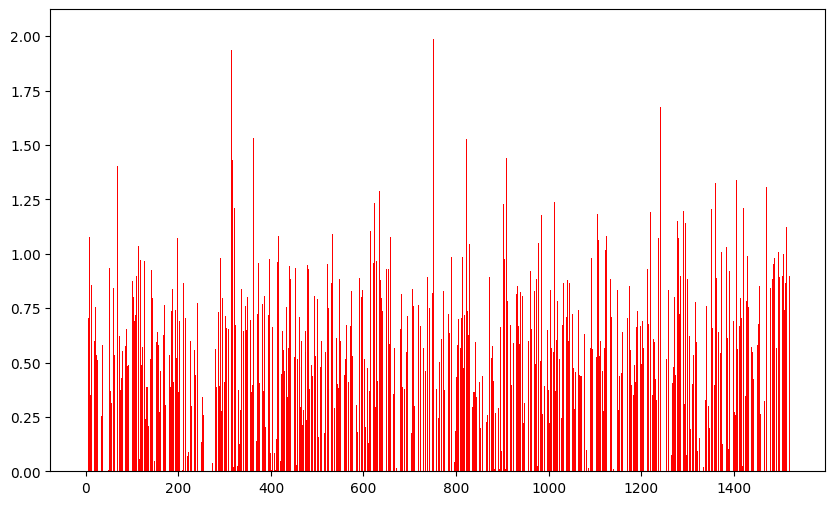

In [24]:
# check trend for LGD, use line chart 
plt.figure(figsize=(10, 6))
plt.bar(range(len(dd_lgd_ead_p['LGD'])),dd_lgd_ead_p['LGD'],color='r')
plt.show()


Text(0.5, 1.0, 'QQ Plot for LGD')

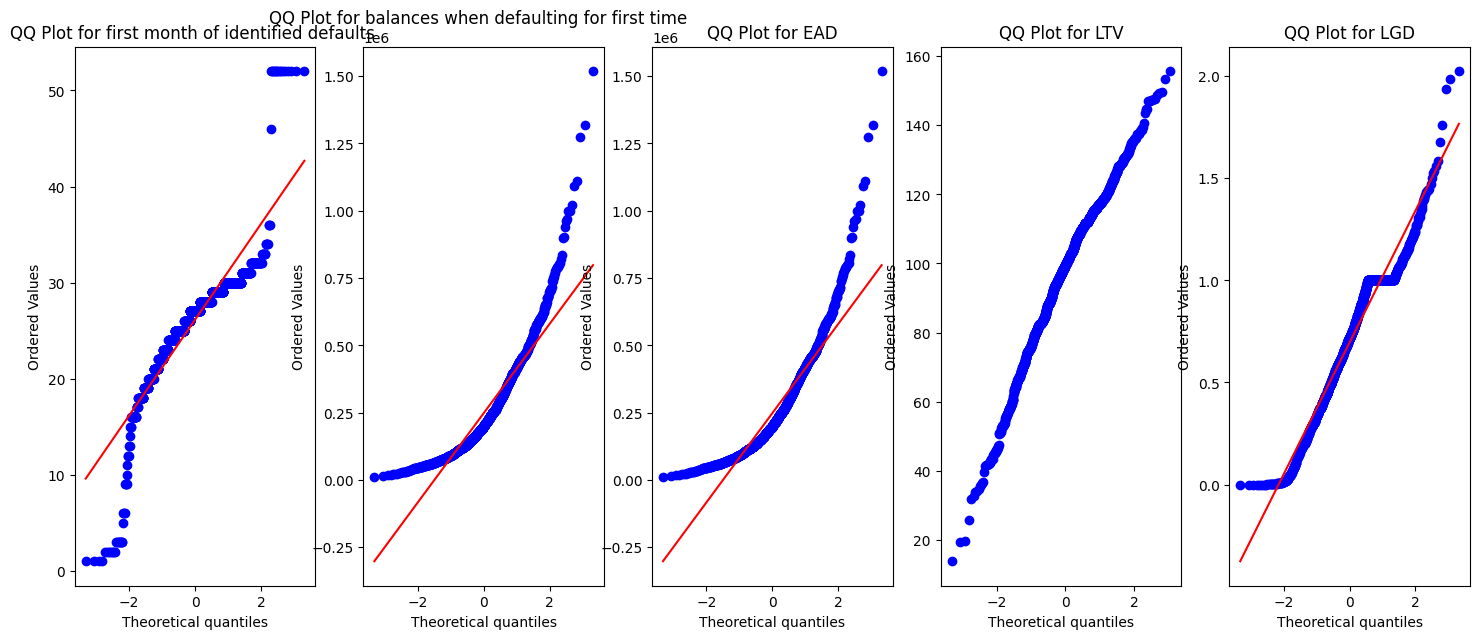

In [158]:
# QQ plots

# Data distribution  visual Test -Step 1 
# Creating QQ plots 
fig, axs = plt.subplots(1, 5, figsize=(18, 7))
stats.probplot(dd_lgd_ead_p['first_time'], dist="norm", plot=axs[0])
axs[0].set_title('QQ Plot for first month of identified defaults ')
stats.probplot(dd_lgd_ead_p['balance_time'], dist="norm", plot=axs[1])
axs[1].set_title('QQ Plot for balances when defaulting for first time  ')
stats.probplot(dd_lgd_ead_p['EAD'], dist="norm", plot=axs[2])
axs[2].set_title('QQ Plot for EAD')
stats.probplot(dd_lgd_ead_p['LTV_time'], dist="norm", plot=axs[3])
axs[3].set_title('QQ Plot for LTV')
stats.probplot(dd_lgd_ead_p['LGD'], dist="norm", plot=axs[4])
axs[4].set_title('QQ Plot for LGD')

(0.0, 1.0, 0.0, 1.0)

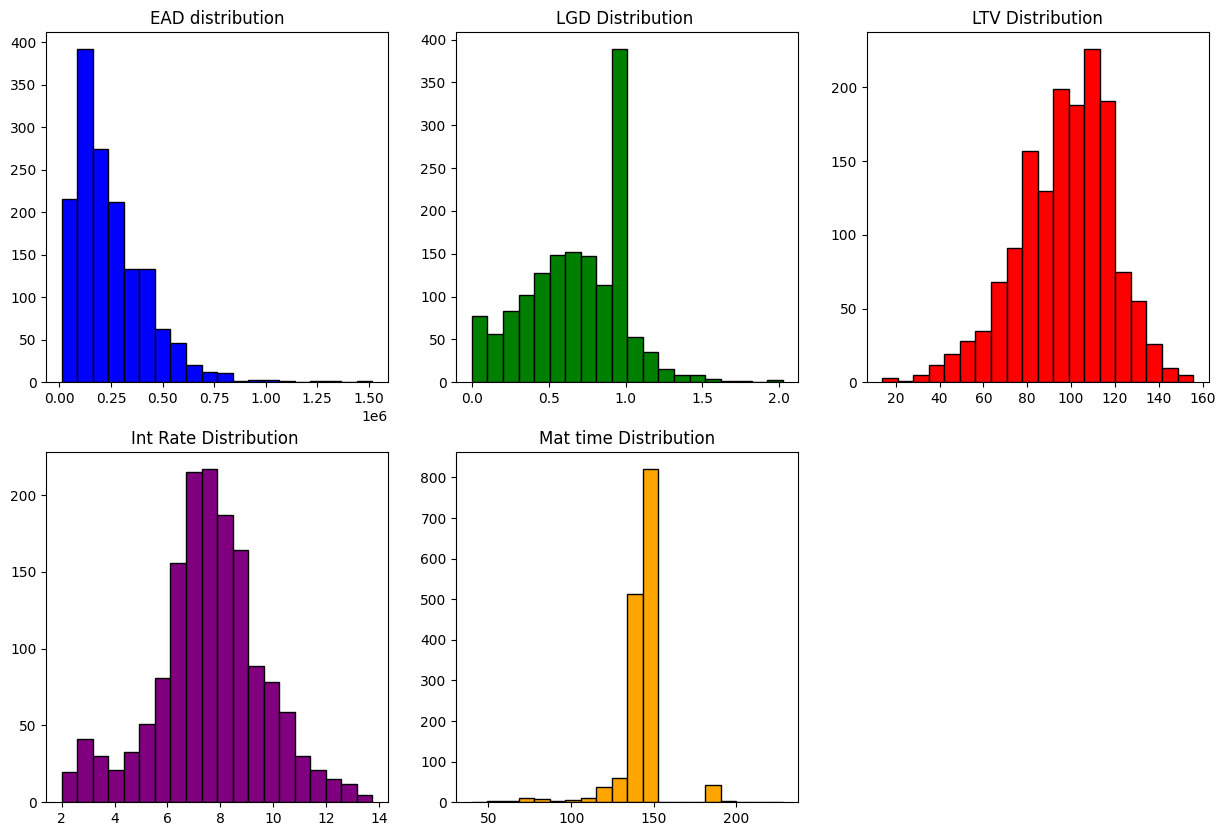

In [159]:
# Trend Analysis on selected variables using Line charts
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(dd_lgd_ead_p['EAD'], bins=20, color='blue', edgecolor='black')
axes[0, 0].set_title('EAD distribution')

axes[0, 1].hist(dd_lgd_ead_p['LGD'], bins=20, color='green', edgecolor='black')
axes[0, 1].set_title('LGD Distribution ')

axes[0, 2].hist(dd_lgd_ead_p['LTV_time'], bins=20, color='red', edgecolor='black')
axes[0, 2].set_title('LTV Distribution')
    
axes[1, 0].hist(dd_lgd_ead_p['int_rate_time'], bins=20, color='purple', edgecolor='black')
axes[1, 0].set_title('Int Rate Distribution ')

axes[1, 1].hist(dd_lgd_ead_p['mat_time'], bins=20, color='orange', edgecolor='black')
axes[1, 1].set_title('Mat time Distribution')

axes[1,2].axis('off')

# Check for outlier and distribution using below visuals 
1. Box plot 
2. Scatter plot 


Text(0.5, 1.0, 'Box Plot - EAD distribution and Opening balances')

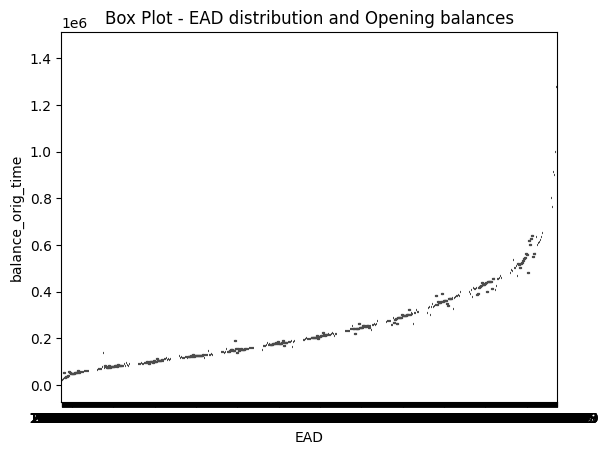

In [19]:
# All Plots for EAD variable 
sns.boxplot(x=dd_lgd_ead_p['EAD'],y=dd_lgd_ead_p['balance_orig_time'],data=dd_lgd_ead_p,color='red')
plt.title('Box Plot - EAD distribution and Opening balances')

Text(0.5, 1.0, 'Scatter Plot - EAD distribution and LTV ')

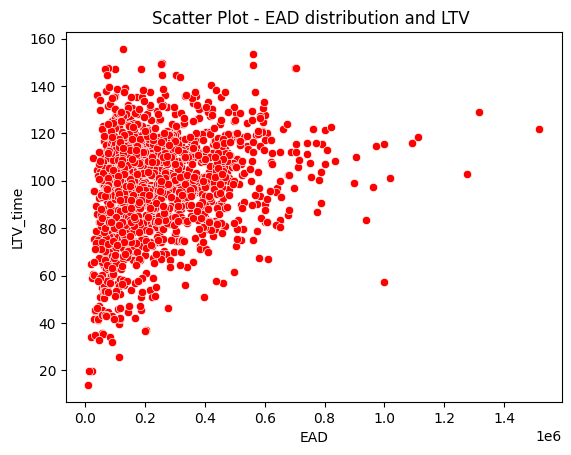

In [178]:
#Check monotonicity of EAD for bank and the balances when loan was originated . This is to know how has the default moved w.r.t origination balances
sns.scatterplot(x=dd_lgd_ead_p['EAD'],y=dd_lgd_ead_p['LTV_time'],color='red')
plt.title('Scatter Plot - EAD distribution and LTV ')

Text(0.5, 1.0, 'Scatter Plot - EAD distribution and Opening Balance ')

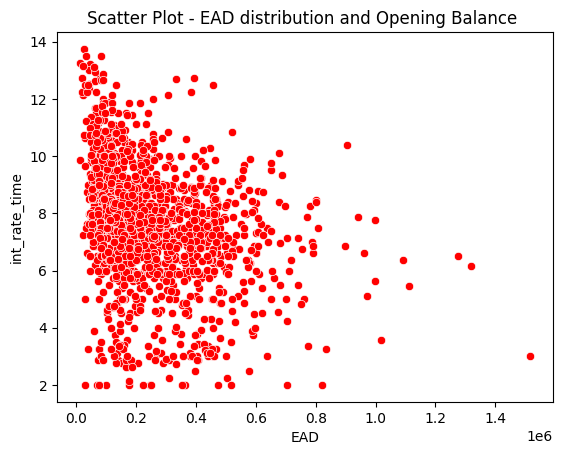

In [162]:
#Check monotonicity of EAD with int rate to see how are exposures moving w.r.t change in int rates
sns.scatterplot(x=dd_lgd_ead_p['EAD'],y=dd_lgd_ead_p['int_rate_time'],color='red')
plt.title('Scatter Plot - EAD distribution and Opening Balance ')

In [83]:
#converting to pandas to execute Shapiro Wilk test and summary statistics of final variables 
lnd_p = lnd.toPandas()
lnd_p.describe()

,_c0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,annual_inc,mths_since_last_delinq
count,832.000000,8.320000e+02,8.320000e+02,832.000000,832.000000,832.000000,832.000000,832.000000,832.000000,832.000000,472.000000
mean,286510.856971,1.762283e+07,1.958943e+07,15284.885817,15284.885817,15279.967293,45.865383,16.136394,455.537296,65611.847500,41.529661
std,121121.621154,1.022619e+07,1.078452e+07,8311.439119,8311.439119,8309.008955,11.815757,4.032109,239.789217,40715.274019,29.123924
min,318.000000,6.093710e+05,7.816300e+05,1000.000000,1000.000000,1000.000000,36.000000,6.490000,33.210000,10000.000000,1.000000
25%,196137.750000,9.388168e+06,1.088521e+07,9600.000000,9600.000000,9600.000000,36.000000,13.350000,288.457500,40000.000000,17.000000
50%,314506.500000,1.624678e+07,1.829457e+07,13675.000000,13675.000000,13675.000000,36.000000,15.800000,398.520000,56254.000000,36.000000
75%,386295.000000,2.519613e+07,2.763922e+07,20000.000000,20000.000000,20000.000000,60.000000,18.990000,580.302500,78653.000000,63.000000
max,465876.000000,3.783081e+07,4.059367e+07,35000.000000,35000.000000,35000.000000,60.000000,26.060000,1300.200000,375000.000000,118.000000


In [21]:
# shapiro Wilk Test
columns_lnd = ['loan_amnt','funded_amnt','funded_amnt_inv','term','int_rate','installment','annual_inc','mths_since_last_delinq']
results_norm = {}
for i in columns_lnd:
    stat,p_value = stats.shapiro(lnd_p[i])
    results_norm[i] = {'statistic':stat,'p_value':p_value}    

In [188]:
for column,result in results_norm.items():
    print(f"Column: {column}")
    print(f"  Shapiro-Wilk Statistic: {result['statistic']:.4f}")
    print(f"  p-value: {result['p_value']:.4f}")
    if result['p_value'] > 5:
        print('data has normal distribution')
    else:
        print('data does not have normal distribution')

Column: loan_amnt
  Shapiro-Wilk Statistic: 0.9425
  p-value: 0.0000
data does not have normal distribution
Column: funded_amnt
  Shapiro-Wilk Statistic: 0.9425
  p-value: 0.0000
data does not have normal distribution
Column: funded_amnt_inv
  Shapiro-Wilk Statistic: 0.9425
  p-value: 0.0000
data does not have normal distribution
Column: term
  Shapiro-Wilk Statistic: nan
  p-value: 1.0000
data does not have normal distribution
Column: int_rate
  Shapiro-Wilk Statistic: 0.9910
  p-value: 0.0001
data does not have normal distribution
Column: installment
  Shapiro-Wilk Statistic: 0.9379
  p-value: 0.0000
data does not have normal distribution
Column: annual_inc
  Shapiro-Wilk Statistic: 0.7765
  p-value: 0.0000
data does not have normal distribution
Column: mths_since_last_delinq
  Shapiro-Wilk Statistic: nan
  p-value: 1.0000
data does not have normal distribution


In [84]:
# replace the col values with KNN algorithm , change K as necessary (convert to pandas, spark doesnt work)
imputer = KNNImputer(n_neighbors=2)
lnd_p['mths_since_last_delinq'] = imputer.fit_transform(lnd_p[['mths_since_last_delinq']])

In [85]:
imputed_data = imputer.fit_transform(lnd_p[['mths_since_last_delinq']])
id_knn1 = imputed_data.mean()

In [23]:
id_knn1

41.52966101694915

# we can conclude that data does not follow normal distribution

# checking these option for Missing data replacement:
1. Minimum of vector
2. Maximum of vector
3. Average of Vector
4. Median of Vector
5. MICE
6. KNN(convert to pandas since spark doesnt support 1D to 2D conversion)
7. Linear Prediction 

In [86]:

# filling up the missing values of mths_since_last_delinq  with the average/min/max values , the selection of the values will be based on best fit measures 
m_del_avg = lnd.select(F.mean(F.col('mths_since_last_delinq'))).first()[0]
m_del_min = lnd.select(F.min(F.col('mths_since_last_delinq'))).first()[0]
m_del_max = lnd.select(F.max(F.col('mths_since_last_delinq'))).first()[0]
m_del_med = lnd.approxQuantile('mths_since_last_delinq',[0.50],0.01)[0]

# replace the col values with avereage 
lnd_avg = lnd.fillna({'mths_since_last_delinq' : m_del_avg})

# replace the col values with median 
lnd_med = lnd.fillna({'mths_since_last_delinq' : m_del_med})


# replace the col values with min 
lnd_min = lnd.fillna({'mths_since_last_delinq' : m_del_min})


# replace the col values with max 
lnd_max = lnd.fillna({'mths_since_last_delinq' : m_del_max})



# Imputing missing values using Linear Prediction. Not using MICE since the logic requires the data to be 

1. Noisy 
2. Not Linearly related , which is proven otherwise in scatter plot and QQ plots above

Since this is linear data , therefore restricting the application to suggested 6 methods.

Before applying Linear prediction for missing value imputation , checking for corelation using 

1.Heatmaps
2.Guassian Copulas(Good for checking corelation for tail distribution)
3.Corelation Matrix(Pearson)

In [87]:
# selecting the columns 
selected_columns = ['loan_amnt','funded_amnt','funded_amnt_inv','term','int_rate','installment','annual_inc','mths_since_last_delinq']
lnd_p_s = lnd_p[selected_columns]

In [26]:
corr_matrix = lnd_p_s.corr()

In [167]:
corr_matrix

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,annual_inc,mths_since_last_delinq
loan_amnt,1.000000,1.000000,0.999997,0.441391,0.206887,0.941756,0.525011,-0.080053
funded_amnt,1.000000,1.000000,0.999997,0.441391,0.206887,0.941756,0.525011,-0.080053
funded_amnt_inv,0.999997,0.999997,1.000000,0.441334,0.207006,0.941781,0.525142,-0.080093
term,0.441391,0.441391,0.441334,1.000000,0.423568,0.166864,0.165553,0.075596
int_rate,0.206887,0.206887,0.207006,0.423568,1.000000,0.193962,0.003280,-0.020346
installment,0.941756,0.941756,0.941781,0.166864,0.193962,1.000000,0.499029,-0.106615
annual_inc,0.525011,0.525011,0.525142,0.165553,0.003280,0.499029,1.000000,-0.125641
mths_since_last_delinq,-0.080053,-0.080053,-0.080093,0.075596,-0.020346,-0.106615,-0.125641,1.000000


<Axes: >

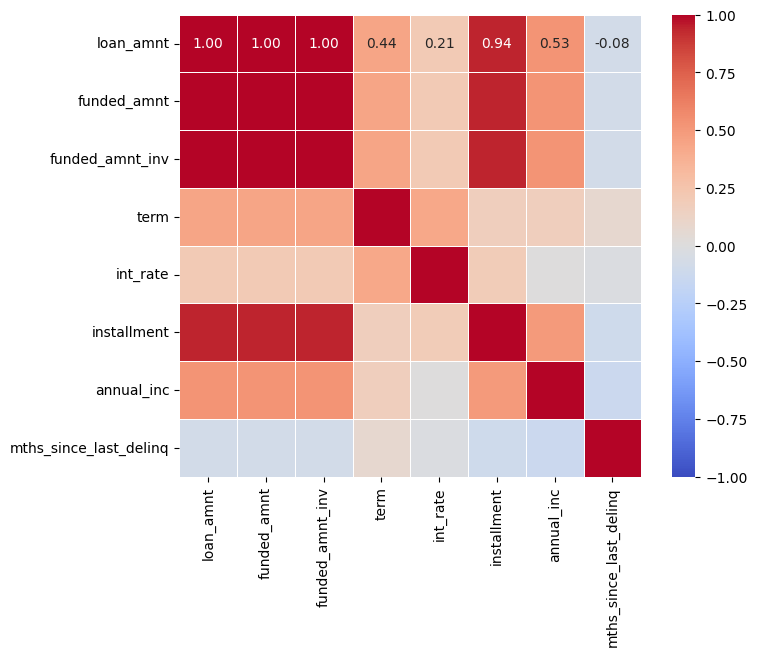

In [168]:
plt.figure(figsize=(8, 6))  # Set the figure size
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, fmt='.2f', square=True)

# From the heatmap and crelation amtrix we can observe that there is high corelation between below variables 

1. Loan and Installment
2. Loan and Funded amount
3. Term has medium corelation with Interest rate
4. Months since last delinquent has 0 or negative corelation , which was expected
5. One final check would be to check the ""condition" of corelation matrix. if this number is greater than 30 then variables are multi collinear. 

### Condition Number Definition

$$ \\
The condition \ number (\kappa(A)) of a matrix (A) is defined as the ratio of the largest singular value (sigma_{text{max}}) to the smallest singular value (sigma_{\text{min}}):
$$

$$ \\
[
kappa(A) = \frac{sigma_{text{max}}}{sigma_{text{min}}}
]
$$

$$ \\
Where : 
- (sigma_{text{max}}) is the largest singular value of (A) 
- (sigma_{text{min}}) is the smallest singular value of (A)
$$


### Singular Value Decomposition (SVD)

The **Singular Value Decomposition (SVD)** of a matrix \( A \) is:

$$ \\
[
A = U \Sigma V^T
]
$$

$$ \\
Where:
- ( U ) and ( V ) are orthogonal matrices (containing the left and right singular vectors),
- ( \Sigma ) is a diagonal matrix containing the singular values \( \sigma_1, \sigma_2, \dots, \sigma_n ) along its diagonal.
$$

The condition number can then be written as:

$$ \\
[
\kappa(A) = \frac{\sigma_1}{\sigma_n}
]
$$


In [153]:
# check condition , number  is 1.15 which is lower than 30 depicting lower multicollenearity 
condition = cond(corr_matrix)

In [88]:
# best value is the average within the threshold of portfolio term requirements therefore using lnd_avg as final dataset 
print(m_del_avg,m_del_min,m_del_max,m_del_med,id_knn1)

41.529661016949156 1 118 36.0 41.52966101694915


In [89]:
# rounding up
lnd_avg = lnd_avg.withColumn('mths_since_last_delinq',F.ceil(lnd_avg.mths_since_last_delinq))

In [24]:
lnd_avg.shape()

(832, 75)

In [ ]:
# dd = dd.select(['id','first_time','mat_time','balance_time','LTV_time','interest_rate_time','hpi_time','gdp_time','balance_orig_time','default_time'])

In [90]:
dd = dd.withColumnRenamed('interest_rate_time','int_rate_time')

In [91]:
lnd_avg = lnd_avg.withColumn('balance_time',(lnd_avg.total_rec_prncp + lnd_avg.total_rec_int + lnd_avg.total_rec_late_fee + lnd_avg.recoveries))

Since there are no LTV , HPI and GDP ratios in loan dataset therefore replacing them with best fit figures from dd_lgd_ead dataset. Using Iterative Imputer to maintain the same distribution for the said variables.

Bayesian ridge method is employed since the data shows linearity(as shown above in graphs) . Bayesian ridge uses linear regression to impute the missing values based on Normality and linear assumptions in data 

Given a dataset where missing values are present in a feature y , we model the data using a linear regression model with a Gaussian likelihood and Gaussian prior on the coefficients.

The linear regression model can be written as:
$$ \\
[
y = X \beta +  \epsilon
] 
$$


where:
   - ($y$) is the target variable (the feature to be imputed),    
   - ($X$) is the matrix of input features (other variables in the dataset),
   - ($beta$) is the vector of regression coefficients,
   - ($epsilon \sim \mathcal{N}(0, \sigma^2)$) is the error term assumed to be normally distributed with mean zero and variance ($sigma^2$).



We assume **Gaussian priors** on the coefficients \( $beta$) and **Inverse Gamma priors** on the noise variance \( $sigma^2$):

$$ \\
[
\beta \sim \mathcal{N}(0, \lambda^{-1} I)
]
$$

where \( $lambda$) is the regularization parameter, and \( $I$) is the identity matrix. For the noise variance:

$$ \\
[
\sigma^2 \sim \text{InvGamma}(a, b)
]
$$


where \( $a$) and \( $b$) are the shape and scale parameters of the Inverse Gamma distribution.




The posterior distribution of \( $beta$) given the data is:
$$ \\
[
p(\beta | X, y) = \mathcal{N}(\hat{\beta}, \Sigma_{\beta})
]
$$

where:
$$ \\
[
\hat{\beta} = (X^T X + \lambda I)^{-1} X^T y
]
$$
is the **maximum a posteriori (MAP) estimate** of the coefficients, and

$$ \\
[
\Sigma_{\beta} = (X^T X + \lambda I)^{-1}
]
$$

is the **posterior covariance matrix** of \( $beta$).



For imputing missing values in the target variable \( y_{\text{missing}} \), we use the following prediction equation:
$$ \\
[
y_{\text{missing}} = X_{\text{missing}} \hat{\beta}
]
$$

where:
 - ($X_{\text{missing}} $) is the row vector for the feature with missing values (i.e., the values of other features in the same row),
 - ( $\hat{\beta}$) is the estimated regression coefficients.


In [92]:
lnd_avg = lnd_avg.withColumn('default_time',F.lit(1))

In [93]:
lnd_avg_p = lnd_avg.toPandas()

In [94]:
imp = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)

lnd_avg_p['LTV_time'] = imp.fit_transform(lnd_avg_p[['dti','revol_util']])[:, 0]
lnd_avg_p['hpi_time'] = imp.fit_transform(lnd_avg_p[['int_rate','dti']])[:, 0]
lnd_avg_p['gdp_time'] = imp.fit_transform(lnd_avg_p[['revol_util','dti']])[:, 0]

In [71]:
lnd_avg_p[['gdp_time','LTV_time','hpi_time']].head(10)

,gdp_time,LTV_time,hpi_time
0,86.7,7.82,17.27
1,40.9,21.07,14.27
2,28.6,19.78,15.99
3,80.5,5.71,20.99
4,25.8,3.43,15.99
5,93.7,20.52,13.43
6,75.9,20.76,15.28
7,87.0,6.94,12.23
8,13.9,2.70,9.99
9,35.2,13.02,21.48


Text(0.5, 1.0, 'HPI Distribution')

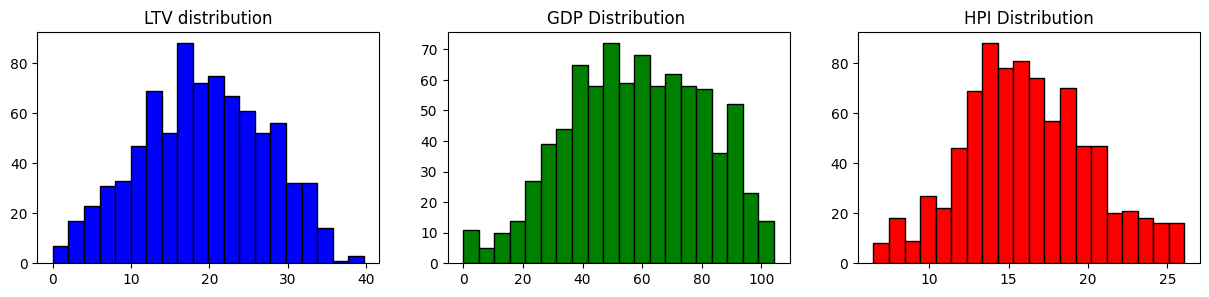

In [242]:
# check for trending of 3 newly created columns 
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

axes[0].hist(lnd_avg_p['LTV_time'], bins=20, color='blue', edgecolor='black')
axes[0].set_title('LTV distribution')

axes[1].hist(lnd_avg_p['gdp_time'], bins=20, color='green', edgecolor='black')
axes[1].set_title('GDP Distribution ')

axes[2].hist(lnd_avg_p['hpi_time'], bins=20, color='red', edgecolor='black')
axes[2].set_title('HPI Distribution')

In [95]:
lnd_avg_p = lnd_avg_p.rename(columns={'funded_amnt' : 'balance_orig_time','int_rate' : 'int_rate_time','mths_since_last_delinq':'first_time','term':'mat_time'})
lnd_avg_p['EAD'] = lnd_avg_p['balance_time']
lnd_avg_p['LGD'] = (lnd_avg_p['balance_orig_time'] - lnd_avg_p['balance_time'])/lnd_avg_p['EAD']

In [30]:
print(len(lnd_avg_p[lnd_avg_p.LGD < 0]))

45


In [96]:
select_col = ['id','first_time','mat_time','balance_time','LTV_time','int_rate_time','hpi_time','gdp_time','balance_orig_time','default_time','EAD','LGD']
lnd_avg_p = lnd_avg_p[select_col]

In [ ]:
# lnd_avg = lnd_avg.select(['id'\
#                           ,'first_time'\
#                           ,'mat_time'\
#                           ,'balance_time'\
#                           ,'LTV_time'\
#                           ,'int_rate_time'\
#                           ,'hpi_time'\
#                           ,'gdp_time'\
#                           ,'balance_orig_time'\
#                           ,'default_time'\
#                           ,'EAD'\
#                           ,'LGD'])


In [97]:
dd_lgd_ead_p = dd_lgd_ead.toPandas() 

In [98]:
lnd_avg_p['Recovery_time'] = 0

In [42]:
dd_lgd_ead_p.dtypes

id                     int32
first_time             int32
mat_time               int32
balance_time         float64
balance_orig_time    float64
EAD                  float64
hpi_time             float64
gdp_time             float64
LTV_time             float64
int_rate_time        float64
default_time           int32
LGD                  float64
Recovery_time        float64
dtype: object

In [38]:
print(dd_lgd_ead_p['Recovery_time'].count())

1060


In [43]:
lnd_avg_p.dtypes

id                     int32
first_time             int64
mat_time             float32
balance_time         float64
LTV_time             float64
int_rate_time        float64
hpi_time             float64
gdp_time             float64
balance_orig_time      int32
default_time           int32
EAD                  float64
LGD                  float64
Recovery_time          int64
dtype: object

In [99]:
df_list = pd.concat([lnd_avg_p,dd_lgd_ead_p],axis=0,ignore_index=True)

In [ ]:
# # Conctenate overall default and loan default dataset for processed dataset that will be used for Survival Analysis. The below code  
# is used to concatenate spark dataframe . The data analysis and imputation was done on python dataframe and not spark.
# df_list = [lnd_avg_p,dd_lgd_ead]
# df = reduce(F.DataFrame.unionByName,df_list)

In [ ]:
#df.select(df.columns[:20]).show(3)

In [100]:
# checking for total sum of missing values , spark and python  code 
# df.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(),c)).alias(c) for c in df.columns]).show()
df_list.isna().sum()

id                     0
first_time             0
mat_time               0
balance_time           0
LTV_time               1
int_rate_time          0
hpi_time               0
gdp_time               0
balance_orig_time      0
default_time           0
EAD                    0
LGD                    0
Recovery_time        465
dtype: int64

In [101]:
df_list['Recovery_time'] = df_list['Recovery_time'].fillna(0)

In [102]:
(df_list['Recovery_time'] != 0).sum()

1060

# Steps for Model building 
1. Understand the data distribution ( completed in above steps)
2. Apply the Survival Function

Not performing normalization of data since survival doesnt require normalization . Also this data doesnt have continous variables therefore there is no need for one hot encoding . Even though normalization is always good to perform for any model but this is more applicable for regression based models such as Lasso, Ridge and Elastic regression because the penalty coeffecients are same for all variables , meaning they dont change as per the variables error distance from the regression line.

In [52]:
df_list.describe()

,id,first_time,mat_time,balance_time,LTV_time,int_rate_time,hpi_time,gdp_time,balance_orig_time,default_time,EAD,LGD,Recovery_time,recovery_rate
count,2.357000e+03,2357.000000,2357.000000,2.357000e+03,2356.000000,2357.000000,2357.000000,2357.000000,2.357000e+03,2357.0,2.357000e+03,2357.000000,2357.000000,2357.000000
mean,6.236791e+06,31.491303,108.482393,1.629932e+05,69.762535,10.599460,119.554268,20.770941,1.660720e+05,1.0,1.629932e+05,0.910354,18.697921,inf
std,1.037519e+07,15.551397,48.140810,1.831538e+05,41.406554,5.019633,79.098758,30.640992,1.792339e+05,0.0,1.831538e+05,0.694556,21.458007,NaN
min,9.000000e+00,1.000000,36.000000,4.430400e+02,0.000000,2.000000,6.490000,-4.146711,0.000000e+00,1.0,4.430400e+02,-0.258704,0.000000,0.187920
25%,2.013300e+04,25.000000,60.000000,9.154820e+03,23.967500,7.125000,18.240000,0.892996,1.935000e+04,1.0,9.154820e+03,0.476196,0.000000,0.585449
50%,3.817400e+04,28.000000,141.000000,1.117962e+05,82.367041,8.875000,154.940000,2.274218,1.147500e+05,1.0,1.117962e+05,0.812312,0.000000,0.982302
75%,1.055772e+07,41.000000,146.000000,2.520000e+05,105.913932,13.980000,180.520000,43.500000,2.520000e+05,1.0,2.520000e+05,1.035661,39.000000,0.999520
max,3.783081e+07,118.000000,228.000000,1.518109e+06,155.613265,26.060000,226.290000,104.200000,1.440000e+06,1.0,1.518109e+06,4.321413,60.000000,inf


In [ ]:
# # manipluate the dataset for LTV , HPI and gdp columns
# coltofill = ['LTV_time','hpi_time','gdp_time']
# for col in coltofill:
#     dfp[col].fillna(dfp[col].mean(),inplace=True)

In [103]:
# make the target variables and perfrom corelation(for linear relationships) and Bayesian Copula for non-linear relationships 
df_list['recovery_rate'] = df_list['balance_time']/df_list['balance_orig_time']

In [104]:
# Survival needs to be done only on positive cash flows between 0 and 1 
dfp_final = df_list[(df_list['recovery_rate'] >= 0) & (df_list['recovery_rate'] <= 1)]

In [114]:
dfp_final.head(5)

,id,first_time,mat_time,balance_time,LTV_time,int_rate_time,hpi_time,gdp_time,balance_orig_time,default_time,...,recovery_rate,Linear_R,LGD_c,Logistic_R,Event_36,Event_48,Event_60,Tied_exit_36,Tied_exit_48,Tied_exit_60
836,191,26,143.0,223884.74,87.176730,7.360,200.67,1.850689,227200.0,1,...,0.985408,0.684305,1.0,0.851293,0,1,1,0,1,1
837,330,28,147.0,144374.85,98.272701,9.045,180.52,0.836859,144790.0,1,...,0.997133,0.725060,0.0,0.822863,0,1,1,0,1,1
838,331,28,147.0,285484.83,89.452618,10.620,200.67,1.850689,286400.0,1,...,0.996805,0.738819,1.0,0.859633,0,0,0,0,0,0
840,343,32,148.0,79140.44,121.463371,8.870,161.00,3.029499,81000.0,1,...,0.977042,0.727658,0.0,0.754714,0,1,1,0,1,1
842,385,32,88.0,150074.42,122.611681,9.820,158.16,-0.241081,161500.0,1,...,0.929253,0.766330,1.0,0.815959,0,1,1,0,1,1


# Performing Logistic & Linear  Regession  

1. Linear Regression : Deriving the LGD with Predicted variables and getting the coeffecients which are best suited
2. Logistic Regerssion : Steps to logistic regression ;
    a.Decide the threshold , ususally between 0.1 to 0.9
    b.Finalize the best beta coeffecient using Newton Raphson algorithm 
    c.Get LGD predictions based on best beta coefficient 

In [105]:
# Linear Regression Model 
# x = np.array(dfp_final[['LTV_time','gdp_time','','mat_time','first_time']])
x = np.array(dfp_final[['LTV_time','int_rate_time','balance_orig_time','mat_time','first_time']])
w = np.array(dfp_final[['EAD']])
l = np.array(dfp_final[['LGD']])
# since there is no constant and for centered R^2 and for intercept measurement adding a scalar array
x_w_c = sm.add_constant(x)

model = sm.WLS(l,x_w_c,weights=w)
results = model.fit()
predictions = np.array(results.fittedvalues)

In [106]:
print("Estimated coefficients (β):")
print(results.params)

Estimated coefficients (β):
[ 6.40994913e-01 -6.61684159e-04  1.88186984e-02 -1.53354484e-07
 -5.64977145e-04  3.00469656e-03]


In [107]:
dfp_final['Linear_R'] = predictions

C:\Users\prashant\AppData\Local\Temp\ipykernel_9196\598301713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp_final['Linear_R'] = predictions


In [39]:
# Centered R square 
mean_lgd = np.mean(l)
ss_total = np.sum(w * (l - mean_lgd)**2)
ss_residual = np.sum(w * (l - predictions)**2)
r_sq_centered = 1 - (ss_residual / ss_total)

In [39]:
r_sq_centered

-1811.3797468134005

In [ ]:
# (18.11%) Negative R square(centered)  signifies that the varation in LGD that can be explained by the independent variables. negative value implies that
# prediction variance in dependent variable is showsing values lower than mean of dependent variable

In [44]:
# R squared in the below summary is not based on EAD weights thefore no relevant for our model
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.045
Model:                            WLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     19.98
Date:                Thu, 29 May 2025   Prob (F-statistic):           1.63e-19
Time:                        08:03:01   Log-Likelihood:                -1806.7
No. Observations:                2116   AIC:                             3625.
Df Residuals:                    2110   BIC:                             3659.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6410      0.094      6.814      0.000       0.457       0.825
x1            -0.0007      0.000     -1.543      0.123      -0.002       0.000
x2             0.0188      0.004      4.812      0.000       0.011       0.026
x3         -1.534e-07   3.73e-08     -4.116      0.000   -2.26e-07   -8.03e-08
x4            -0.0006      0.001     -0.946      0.344      -0.002       0.001
x5             0.0030      0.001      2.308      0.021       0.000       0.006
==============================================================================
Omnibus:                       99.043   Durbin-Watson:                   1.713
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              195.444
Skew:                          -0.329   Prob(JB):                     3.63e-43
Kurtosis:                       4.336   Cond. No.                     5.18e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.18e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [45]:
# check for corelations across variables in final dataset before applying the regression
selected_columnsd = ['first_time', 'mat_time', 'balance_time', 'LTV_time', 'int_rate_time']
dfp_final_c = dfp_final[selected_columnsd]
corr_matrix_f = dfp_final_c.corr()

<Axes: >

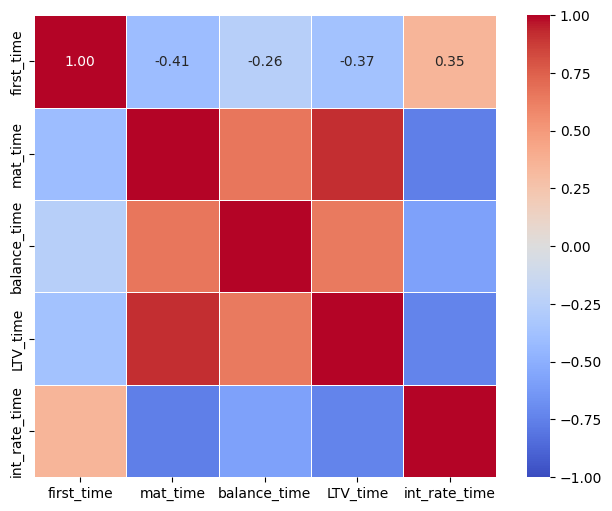

In [50]:
plt.figure(figsize=(8, 6))  # Set the figure size
sns.heatmap(corr_matrix_f, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, fmt='.2f', square=True)

# Logistic Regression

1. Classify the LGD as low and high
2. Calculate EAD weighted mean and low and high values
3. use Raphson Neuton algorithm to calculate the best coeffecient 


In [108]:
# low indicator means 1 and high means 0
dfp_final['LGD_c'] = np.where(dfp_final['LGD'] < 1,1,0) 
dfp_final['LGD_c'] = dfp_final.LGD_c.astype(float)

C:\Users\prashant\AppData\Local\Temp\ipykernel_9196\1379831798.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp_final['LGD_c'] = np.where(dfp_final['LGD'] < 1,1,0)
C:\Users\prashant\AppData\Local\Temp\ipykernel_9196\1379831798.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp_final['LGD_c'] = dfp_final.LGD_c.astype(float)


In [109]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler

class LogisticRegressionLGD:
    def __init__(self, l_threshold=1):
        self.l_threshold = l_threshold  # Threshold for low LGD
        self.beta_ = None
        self.scaler = StandardScaler()
    
    def logistic_function(self, x, beta):
        z = np.dot(x, beta)
        z = np.clip(z, -100, 100)  # Clip to prevent overflow
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y, EAD):
        # Standardize features to prevent extreme values
        X_scaled = self.scaler.fit_transform(X)
        
        # Define likelihood function
        def likelihood(beta):
            logit = self.logistic_function(X_scaled, beta)
            eps = 1e-10  # Small value to prevent log(0)
            logit = np.clip(logit, eps, 1 - eps)
            loss = -np.sum(EAD * (y * np.log(logit) + (1 - y) * np.log(1 - logit)))
            return loss
        
        # Optimize using L-BFGS-B for numerical stability since the data has extreme values and is imbalanced . Also L-BGFS-B is more applicable
        # for constrained problems like LR 
        beta_init = np.zeros(X_scaled.shape[1])
        opt_result = minimize(likelihood, beta_init, method="L-BFGS-B")
        
        if opt_result.success:
            self.beta_ = opt_result.x
        else:
            raise ValueError("Optimization failed to converge")
        
    def predict(self, X):
        X_scaled = self.scaler.transform(X)  # Apply the same scaling
        return self.logistic_function(X_scaled, self.beta_)

# Define target and features
threshold = 1
EAD = dfp_final['EAD'].values
y = (dfp_final['LGD'] < threshold).astype(int)  # 1 for low LGD, 0 for high LGD
LGD = dfp_final['LGD'].values
X = dfp_final[['first_time', 'mat_time', 'balance_time', 'LTV_time', 'int_rate_time']].values

# Train the logistic regression model
model = LogisticRegressionLGD(l_threshold=threshold)
model.fit(X, y, EAD)

# Predict probability of "low" LGD
predicted_prob = model.predict(X)

# Calculate Ex-Ante LGD
low_LGD_mean = np.mean(LGD[y == 1])  # Mean LGD for low LGD cases
high_LGD_mean = np.mean(LGD[y == 0])  # Mean LGD for high LGD cases

L = predicted_prob * low_LGD_mean + (1 - predicted_prob) * high_LGD_mean

# Output results
print("Estimated Ex-Ante LGD for the accounts:")
print(L[:10])  # Display the first 10 results


Estimated Ex-Ante LGD for the accounts:
[1.39334828 1.39244972 1.34350113 1.30794157 1.40196445 1.35684216
 1.35400803 1.39311762 1.29715906 1.22435256]


In [110]:
dfp_final['Logistic_R'] = L

C:\Users\prashant\AppData\Local\Temp\ipykernel_9196\2418237842.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp_final['Logistic_R'] = L


In [ ]:
#dfp_final = dfp_final.drop(columns=['pi_estimated', 'L_a'])

In [49]:
#dfp_final.columns = [col.replace('time','') if 'time' in col else col for col in dfp_final.columns]

In [49]:
dfp_final.head(10)

,id,first_time,mat_time,balance_time,LTV_time,int_rate_time,hpi_time,gdp_time,balance_orig_time,default_time,EAD,LGD,Recovery_time,recovery_rate,Linear_R,LGD_c,Logistic_R
9,10144970,41,60.0,6556.12,13.02,21.48,21.48,35.2,12000.0,1,6556.12,0.830351,0.0,0.546343,1.124059,1.0,1.393348
10,10034724,41,36.0,2509.62,11.66,14.98,14.98,29.2,3600.0,1,2509.62,0.434480,0.0,0.697117,1.017485,1.0,1.392450
11,9857791,41,36.0,7588.40,25.49,11.99,11.99,71.4,11425.0,1,7588.40,0.505587,0.0,0.664193,0.950866,1.0,1.343501
12,9846956,15,36.0,5977.78,14.04,11.99,11.99,26.3,9000.0,1,5977.78,0.505576,0.0,0.664198,0.880692,1.0,1.307942
13,9806725,58,60.0,8051.08,18.61,17.57,17.57,56.4,16000.0,1,8051.08,0.987311,0.0,0.503193,1.097246,1.0,1.401964
14,9826644,41,60.0,9778.40,19.54,16.24,16.24,71.9,20000.0,1,9778.40,1.045324,0.0,0.488920,1.019908,0.0,1.356842
15,9834845,14,36.0,6525.52,4.44,16.24,16.24,63.5,9250.0,1,6525.52,0.417512,0.0,0.705462,0.963981,1.0,1.354008
16,9765407,59,60.0,6254.88,25.59,19.22,19.22,52.9,12000.0,1,6254.88,0.918502,0.0,0.521240,1.127296,1.0,1.393118
17,9874901,6,60.0,20384.33,19.39,24.50,24.50,80.2,35000.0,1,20384.33,0.717005,0.0,0.582409,1.067985,1.0,1.297159
18,9834837,1,60.0,16873.78,21.79,15.61,15.61,61.4,35000.0,1,16873.78,1.074224,0.0,0.482108,0.884075,0.0,1.224353


# Model SURVIVAL Analysis

Dataset needs to have recovery amounts so that the RCF and CRCF could be calculated 
Recovery process for this stated bank is 3 years(60 months from the data)

Survival is probability of an accounts survival until an event happens(death or before the recovery term finishes) 
hazard ratio is the rate of no collections untill the time of event which could be end of term or before the period allotted to applicant for the recovery
Censoring from Survival analysis LGD concept is to assess the probability of full recovery before the event. Therefore cases which are still undergoing and have not been recovered  are part of censoring dataset. 

The paper uses below methods to assess the survival probability 

 Cox Semi proportional 
 Weibull 
 Log Normal 

60 months is the time to the event(meaning when the recovery process finishes)
36 months has been taken to provide for an evenly adjusted population of 70% for  completed cases and 30% for censored cases 

$$
Estimating $beta$ :

beta is estimated using partial likelihood, Newton-Raphson algorithm is used to estimate the beta coefficients when we are assuming there is only 1 exit at a time  howveer for recoveries "ties" are supposed to be considered as well which means multiple exits are time t. We would be using Breslow and Efron estimates for handling ties (multiple exits) at one time.
$$


In [ ]:
#LGD dataset has recovery process when it was initiated 
# Default dataset(1525) is the summarization of Loan(304) and Loss Dataset(1221)
# recovery data is only part of LGD dataset 


In [111]:
dfp_final = dfp_final[dfp_final['Recovery_time'] != 0]

In [46]:
# total population is Lower number than starting population since the model is built on the default cases where recovery process is still ongoing.
dfp_final.columns

Index(['id', 'first_time', 'mat_time', 'balance_time', 'LTV_time',
       'int_rate_time', 'hpi_time', 'gdp_time', 'balance_orig_time',
       'default_time', 'EAD', 'LGD', 'Recovery_time', 'recovery_rate'],
      dtype='object')

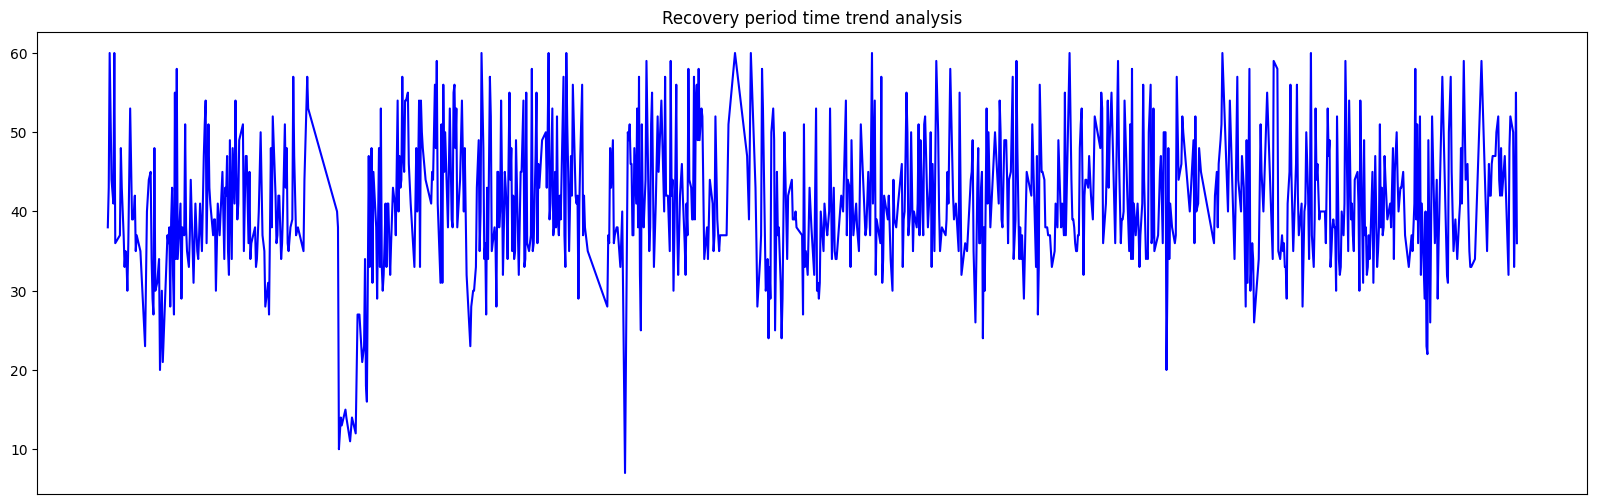

In [107]:
# check recovery time trend
plt.figure(figsize=(20, 6))
plt.plot(dfp_final['Recovery_time'],linestyle='-',color='b')
plt.gca().get_xaxis().set_visible(False)
plt.title('Recovery period time trend analysis')
plt.show()

# Definition of events - 36,48 and 60 months

In [44]:
dfp_final['Event_36'] = [1 if col < 36 else 0 for col in dfp_final['Recovery_time']]
dfp_final['Event_48'] = [1 if col < 48 else 0 for col in dfp_final['Recovery_time']]
dfp_final['Event_60'] = [1 if col < 60 else 0 for col in dfp_final['Recovery_time']]

#dfp_final['Event'] = np.where(dfp_final['Recovery_time'] <60,0,1]

In [75]:
dfp_final['Event_36'].value_counts().to_frame(name='Count').assign(percentage=lambda x: (x['Count']/x['Count'].sum()) * 100)

,Count,percentage
Event_36,,
0,700,74.547391
1,239,25.452609


In [51]:
dfp_final.shape

(939, 17)

In [ ]:
# These represent the probability that recovery has not occured by 36,48,60 months i.e survival of non-recovery(default state)

In [45]:
# Identify ties in Recovery time column
ties_36 = dfp_final.groupby('Recovery_time')['Event_36'].count()
ties_48 = dfp_final.groupby('Recovery_time')['Event_48'].count()
ties_60 = dfp_final.groupby('Recovery_time')['Event_60'].count()

In [46]:
# Performing tied exits at various intervals - 36
ties_36 = ties_36[ties_36 > 1]
tied_times_36 = ties_36.index
tied_exits_df_36 = dfp_final[dfp_final['Recovery_time'].isin(tied_times_36)]

In [47]:
# Performing tied exits at various intervals - 48
ties_48 = ties_48[ties_48 > 1]
tied_times_48 = ties_48.index
tied_exits_df_48 = dfp_final[dfp_final['Recovery_time'].isin(tied_times_48)]

In [48]:
# Performing tied exits at various intervals - 60
ties_60 = ties_60[ties_60 > 1]
tied_times_60 = ties_60.index
tied_exits_df_60 = dfp_final[dfp_final['Recovery_time'].isin(tied_times_60)]

In [49]:
# getting rid of time suffixes in column headers 
tied_exits_df_36.columns = [col.replace('_time','') if '_time' in col else col for col in tied_exits_df_36.columns]
tied_exits_df_48.columns = [col.replace('_time','') if '_time' in col else col for col in tied_exits_df_48.columns]
tied_exits_df_60.columns = [col.replace('_time','') if '_time' in col else col for col in tied_exits_df_60.columns]


In [112]:
# Step 1: Create event indicators for recovery before each horizon
dfp_final['Event_36'] = (dfp_final['Recovery_time'] < 36).astype(int)
dfp_final['Event_48'] = (dfp_final['Recovery_time'] < 48).astype(int)
dfp_final['Event_60'] = (dfp_final['Recovery_time'] < 60).astype(int)

# Step 2: Identify tied recovery times for each exit horizon
ties_count = dfp_final.groupby('Recovery_time').size()

# Step 3: Create new columns in dfp_final to flag tied exit points
dfp_final['Tied_exit_36'] = dfp_final['Recovery_time'].isin(ties_count[ties_count > 1].index) & (dfp_final['Recovery_time'] < 36)
dfp_final['Tied_exit_48'] = dfp_final['Recovery_time'].isin(ties_count[ties_count > 1].index) & (dfp_final['Recovery_time'] < 48)
dfp_final['Tied_exit_60'] = dfp_final['Recovery_time'].isin(ties_count[ties_count > 1].index) & (dfp_final['Recovery_time'] < 60)

# Optional: convert boolean to int (if needed for modeling)
dfp_final['Tied_exit_36'] = dfp_final['Tied_exit_36'].astype(int)
dfp_final['Tied_exit_48'] = dfp_final['Tied_exit_48'].astype(int)
dfp_final['Tied_exit_60'] = dfp_final['Tied_exit_60'].astype(int)

In [116]:
dfp_final.head(5)

,id,first_time,mat_time,balance_time,LTV_time,int_rate_time,hpi_time,gdp_time,balance_orig_time,default_time,...,recovery_rate,Linear_R,LGD_c,Logistic_R,Event_36,Event_48,Event_60,Tied_exit_36,Tied_exit_48,Tied_exit_60
836,191,26,143.0,223884.74,87.176730,7.360,200.67,1.850689,227200.0,1,...,0.985408,0.684305,1.0,0.851293,0,1,1,0,1,1
837,330,28,147.0,144374.85,98.272701,9.045,180.52,0.836859,144790.0,1,...,0.997133,0.725060,0.0,0.822863,0,1,1,0,1,1
838,331,28,147.0,285484.83,89.452618,10.620,200.67,1.850689,286400.0,1,...,0.996805,0.738819,1.0,0.859633,0,0,0,0,0,0
840,343,32,148.0,79140.44,121.463371,8.870,161.00,3.029499,81000.0,1,...,0.977042,0.727658,0.0,0.754714,0,1,1,0,1,1
842,385,32,88.0,150074.42,122.611681,9.820,158.16,-0.241081,161500.0,1,...,0.929253,0.766330,1.0,0.815959,0,1,1,0,1,1


C:\Users\prashant\anaconda3\envs\modeling\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\prashant\anaconda3\envs\modeling\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\prashant\anaconda3\envs\modeling\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\prashant\anaconda3\envs\modeling\lib\site-packag

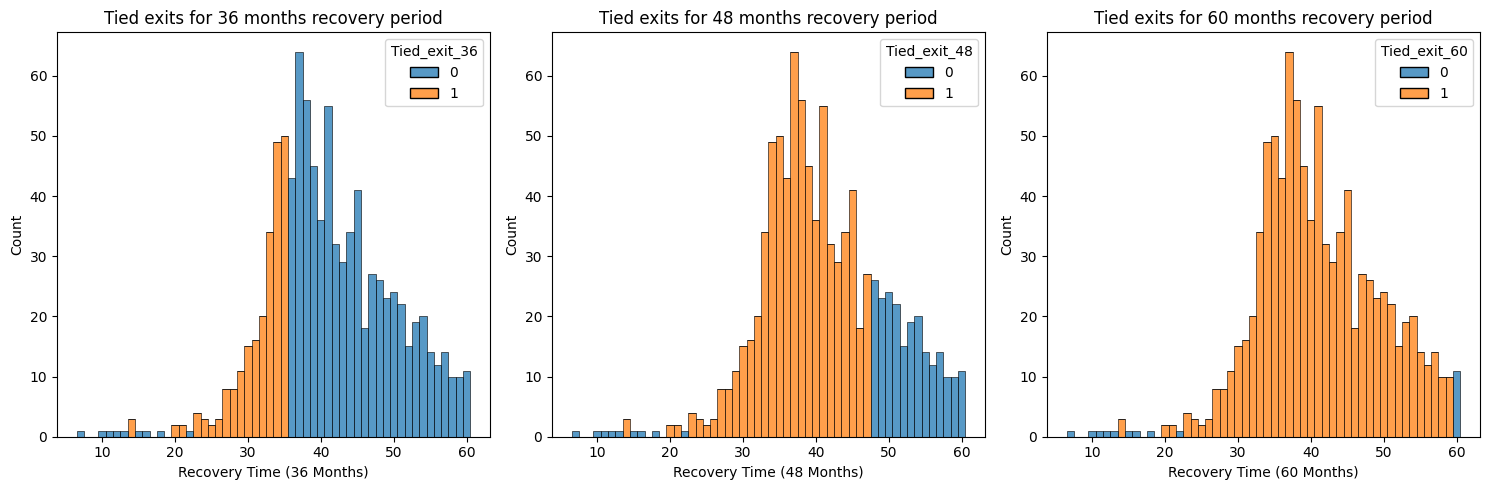

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(data=dfp_final, x='Recovery_time', discrete=True, hue='Tied_exit_36', multiple="stack", ax=axes[0])
axes[0].set_title('Tied exits for 36 months recovery period')
axes[0].set_xlabel("Recovery Time (36 Months)")
axes[0].set_ylabel("Count")

sns.histplot(data=dfp_final, x='Recovery_time', discrete=True, hue='Tied_exit_48', multiple="stack", ax=axes[1])
axes[1].set_title('Tied exits for 48 months recovery period')
axes[1].set_xlabel("Recovery Time (48 Months)")
axes[1].set_ylabel("Count")

sns.histplot(data=dfp_final, x='Recovery_time', discrete=True, hue='Tied_exit_60', multiple="stack", ax=axes[2])
axes[2].set_title('Tied exits for 60 months recovery period')
axes[2].set_xlabel("Recovery Time (60 Months)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

<Axes: >

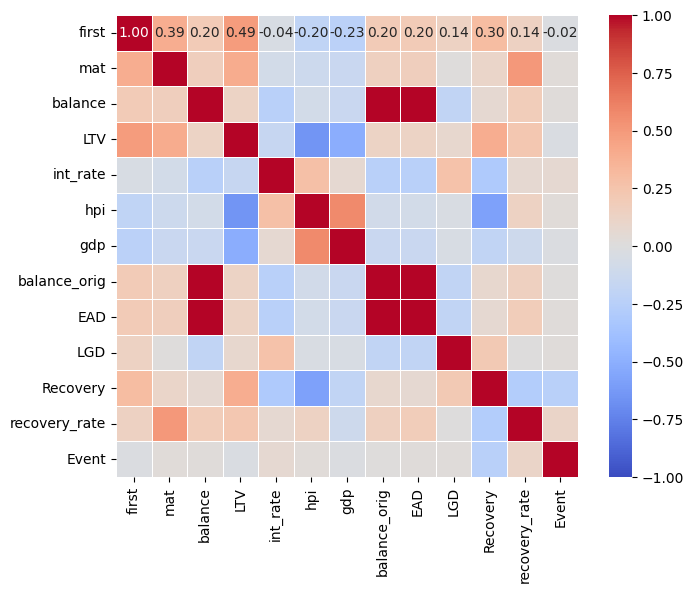

In [61]:
# after selecting and understanding the number of exits per time period we are confirmed to use the Brenslow Efron mrthod 
# checking for corelations 
d_cols = ['id','default']
tes = df_final.drop(columns=d_cols)
tes_c = tes.corr()
plt.figure(figsize=(8, 6))  # Set the figure size
sns.heatmap(tes_c, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, fmt='.2f', square=True)

                   coef  exp(coef)      se(coef)  coef lower 95%  \
covariate                                                          
EAD        1.458001e-07   1.000000  4.239497e-07   -6.851260e-07   
LGD       -1.672913e+00   0.187699  1.943511e-01   -2.053835e+00   
gdp        7.405629e-01   2.097116  8.066537e-02    5.824617e-01   
LTV       -3.202300e-02   0.968484  3.466597e-03   -3.881741e-02   

           coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  cmp to  \
covariate                                                                     
EAD          9.767263e-07             0.999999             1.000001     0.0   
LGD         -1.291992e+00             0.128242             0.274723     0.0   
gdp          8.986641e-01             1.790441             2.456320     0.0   
LTV         -2.522859e-02             0.961926             0.975087     0.0   

                  z             p   -log2(p)  
covariate                                     
EAD        0.343909  7

C:\Users\prashant\AppData\Local\Temp\ipykernel_21228\504736460.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tied_exits_df[f'Survival_proba_{t}'] = survival_prob.loc[t].values
C:\Users\prashant\AppData\Local\Temp\ipykernel_21228\504736460.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tied_exits_df[f'Survival_proba_{t}'] = survival_prob.loc[t].values
C:\Users\prashant\AppData\Local\Temp\ipykernel_21228\504736460.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

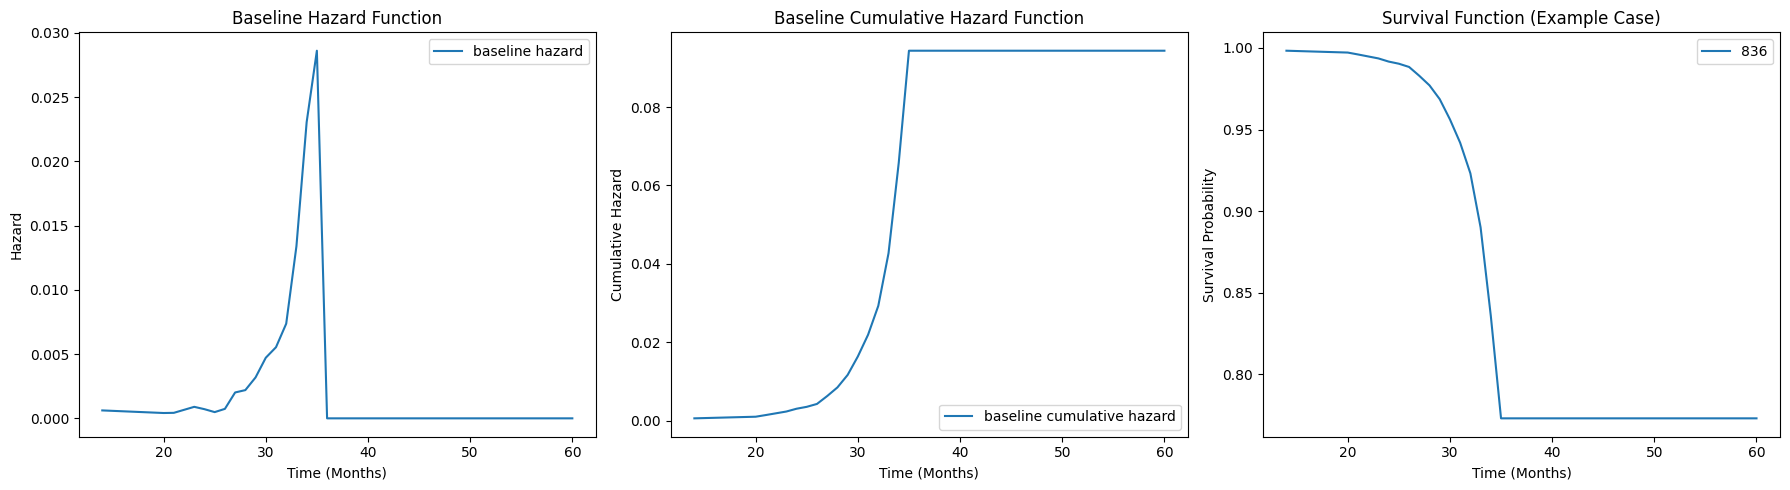

In [100]:
# Fit Cox Proportional Hazards model (default: Breslow method)
cph = CoxPHFitter()
cph.fit(tied_exits_df, duration_col="Recovery", event_col="Event", formula="EAD + LGD + gdp + LTV")

# Summary of beta coefficients
print(cph.summary)

example_data = tied_exits_df.iloc[[0]]  # for visualization Change index to explore other observations 

# Predict survival function over time for all observations 
survival_prob = cph.predict_survival_function(tied_exits_df)

target_time = [36,48,60]
for t in target_time:
    tied_exits_df[f'Survival_proba_{t}'] = survival_prob.loc[t].values
tied_exits_df['Partial_hazard'] = cph.predict_partial_hazard(tied_exits_df).values # higher the value , higher the recovery for collections
# tied_exits_df['Surviva_prob_60'] = survival_prob.loc[target_time_60].values
survival_func = cph.predict_survival_function(example_data)
cum_hazard_func = cph.predict_cumulative_hazard(example_data)
#hazard_func = cph.predict_survival_function(tied_exits_df)

# Step 5: Plot all three graphs together
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Baseline Hazard
cph.baseline_hazard_.plot(ax=axes[0])
axes[0].set_title("Baseline Hazard Function")
axes[0].set_xlabel("Time (Months)")
axes[0].set_ylabel("Hazard")

# Plot 2: Baseline Cumulative Hazard
cph.baseline_cumulative_hazard_.plot(ax=axes[1])
axes[1].set_title("Baseline Cumulative Hazard Function")
axes[1].set_xlabel("Time (Months)")
axes[1].set_ylabel("Cumulative Hazard")

# Plot 3: Survival Function for One Observation
survival_func.plot(ax=axes[2])
axes[2].set_title("Survival Function (Example Case)")
axes[2].set_xlabel("Time (Months)")
axes[2].set_ylabel("Survival Probability")

plt.tight_layout()
plt.show()

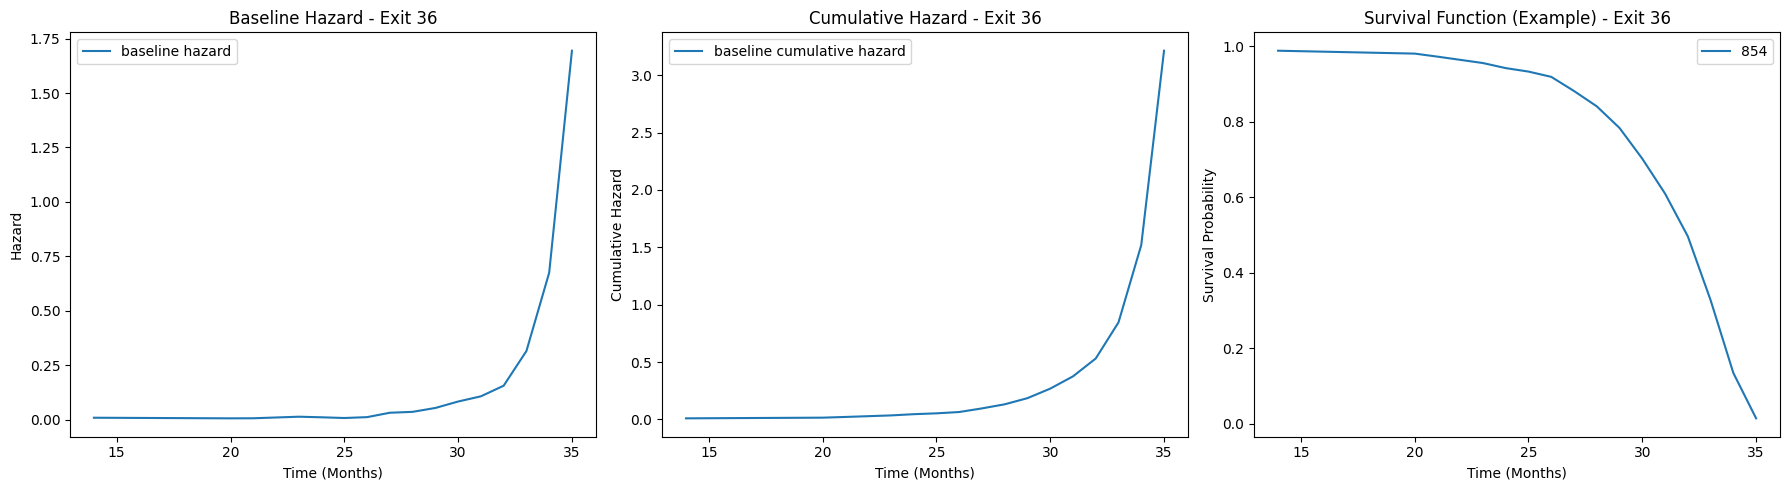

Model summary for Exit 36 months:
               coef  exp(coef)      se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                      
EAD       -0.000001   0.999999  4.278420e-07       -0.000002   -2.066569e-07   
LGD       -0.962226   0.382041  2.341672e-01       -1.421186   -5.032672e-01   
gdp_time   0.822841   2.276961  1.292137e-01        0.569587    1.076096e+00   
LTV_time  -0.010926   0.989133  5.520357e-03       -0.021746   -1.062815e-04   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
EAD                   0.999998             1.000000     0.0 -2.442985   
LGD                   0.241428             0.604552     0.0 -4.109143   
gdp_time              1.767537             2.933205     0.0  6.368065   
LTV_time              0.978489             0.999894     0.0 -1.979217   

                      p   -log2(p)  
covariate

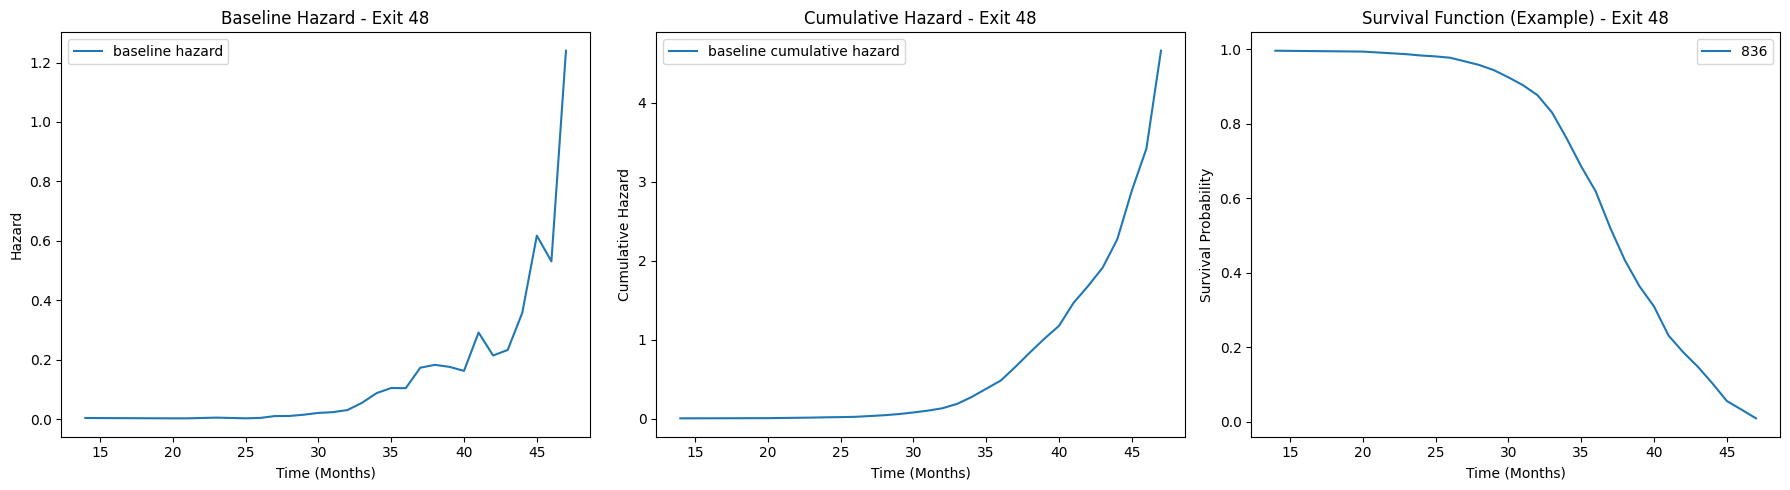

Model summary for Exit 48 months:
                   coef  exp(coef)      se(coef)  coef lower 95%  \
covariate                                                          
EAD       -7.593193e-07   0.999999  2.589522e-07       -0.000001   
LGD       -1.074171e+00   0.341581  1.242544e-01       -1.317705   
gdp_time   7.412563e-02   1.076942  1.797481e-02        0.038896   
LTV_time  -1.819547e-02   0.981969  2.169331e-03       -0.022447   

           coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  cmp to  \
covariate                                                                     
EAD         -2.517823e-07             0.999999             1.000000     0.0   
LGD         -8.306370e-01             0.267749             0.435772     0.0   
gdp_time     1.093556e-01             1.039662             1.115559     0.0   
LTV_time    -1.394366e-02             0.977803             0.986153     0.0   

                  z             p   -log2(p)  
covariate                          

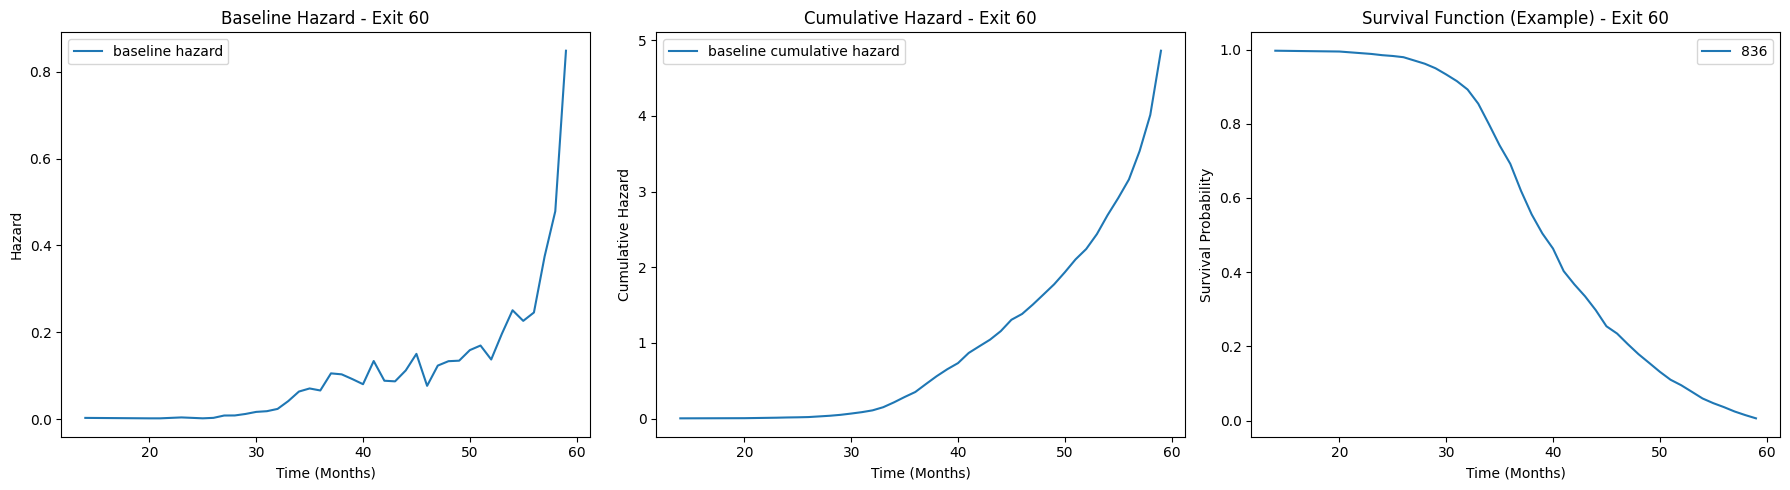

Model summary for Exit 60 months:
                   coef  exp(coef)      se(coef)  coef lower 95%  \
covariate                                                          
EAD       -7.780903e-08   1.000000  2.265035e-07   -5.217478e-07   
LGD       -3.676697e-01   0.692346  9.448157e-02   -5.528502e-01   
gdp_time  -4.728548e-03   0.995283  1.555528e-02   -3.521633e-02   
LTV_time  -1.415969e-02   0.985940  1.779306e-03   -1.764707e-02   

           coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  cmp to  \
covariate                                                                     
EAD          3.661297e-07             0.999999             1.000000     0.0   
LGD         -1.824893e-01             0.575308             0.833194     0.0   
gdp_time     2.575923e-02             0.965397             1.026094     0.0   
LTV_time    -1.067232e-02             0.982508             0.989384     0.0   

                  z             p   -log2(p)  
covariate                          

In [121]:
# Set time horizons
exit_points = [36, 48, 60]

# Loop through each exit point
for t in exit_points:
    event_col = f'Event_{t}'
    tied_flag = f'Tied_exit_{t}'
    
    # Filter the tied exits for this time horizon
    df_subset = dfp_final[dfp_final[tied_flag] == 1].copy()
    
    if df_subset.empty:
        print(f"No tied exits found for {t} months.")
        continue
    
    # Fit the Cox model
    cph = CoxPHFitter()
    cph.fit(df_subset, duration_col="Recovery_time", event_col=event_col, formula="EAD + LGD + gdp_time + LTV_time")
    
    # Predict survival probabilities at 36, 48, 60 for the subset
    survival_prob = cph.predict_survival_function(df_subset, times=exit_points)
    
    # Store predictions in the original dfp_final by index
    for tp in exit_points:
        dfp_final.loc[df_subset.index, f'Survival_proba_{tp}_exit_{t}'] = survival_prob.loc[tp].values
        dfp_final.loc[df_subset.index, f'Recovery_proba_{tp}_exit_{t}'] = 1 - survival_prob.loc[tp].values

    # Partial hazard and median recovery time
    dfp_final.loc[df_subset.index, f'Partial_hazard_exit_{t}'] = cph.predict_partial_hazard(df_subset).values
    dfp_final.loc[df_subset.index, f'Median_recovery_exit_{t}'] = cph.predict_median(df_subset)

    # Optional visualization for first observation of this exit group
    example_data = df_subset.iloc[[0]]
    survival_func = cph.predict_survival_function(example_data)
    cum_hazard_func = cph.predict_cumulative_hazard(example_data)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    cph.baseline_hazard_.plot(ax=axes[0])
    axes[0].set_title(f"Baseline Hazard - Exit {t}")
    axes[0].set_xlabel("Time (Months)")
    axes[0].set_ylabel("Hazard")
    
    cph.baseline_cumulative_hazard_.plot(ax=axes[1])
    axes[1].set_title(f"Cumulative Hazard - Exit {t}")
    axes[1].set_xlabel("Time (Months)")
    axes[1].set_ylabel("Cumulative Hazard")
    
    survival_func.plot(ax=axes[2])
    axes[2].set_title(f"Survival Function (Example) - Exit {t}")
    axes[2].set_xlabel("Time (Months)")
    axes[2].set_ylabel("Survival Probability")
    
    plt.tight_layout()
    plt.show()

    print(f"Model summary for Exit {t} months:")
    print(cph.summary)

## Analysis on the graph and the model summary 

The LGD survival function is showing a downward trend as expected since the propensity of recovery goes down as the recovery period comes to an end

## EAD

EAD has a positive coefficient for hazard(speed of recovery) but the value is very low meaning it doesnt have much affect on the hazard rate(speed of recovery). ALso the p-value is very high which means the vairable is insignificant and doesnt not affect the speed of recovery.

## LGD 

LGD has a negative coefficient for hazard therefore larger LGD values shows negative recovery rate . Also 28% decrese per unit of hazard for 1 unit  increase in LGD. 
low p-value shows  significance of the coeffecient .
LGD is  strong predictor of recovery time.

## GDP 

GDP has positive affect on the hazard rate means with increase in  gdp warrants for higher speed of recovery with significant p-value as well which means it is strong contributor


## LTV 

LTV shows negative coefficient since higher loan to  collaterall values signifies more leverage and lower hazard rate(chance of recovery).Negative coeffecient shows negative affect on hazard.Hazard drop 1.5% per unit increase in LTV.P-value is also very highly significant showing strong predictor of hazard rate.(speec fo recovery)



In [103]:
tied_exits_df.head(5)
df = tied_exits_df.copy()

,id,first,mat,balance,LTV,int_rate,hpi,gdp,balance_orig,default,...,recovery_rate,Linear_R,LGD_c,Logistic_R,Event,Partial_hazard,Surviva_prob_60,Survival_proba_36,Survival_proba_48,Survival_proba_60
836,191,26,143.0,223884.74,87.176730,7.360,200.67,1.850689,227200.0,1,...,0.985408,0.684305,1.0,0.851293,0,2.729414,0.772942,0.772942,0.772942,0.772942
837,330,28,147.0,144374.85,98.272701,9.045,180.52,0.836859,144790.0,1,...,0.997133,0.725060,0.0,0.822863,0,0.495101,0.954356,0.954356,0.954356,0.954356
838,331,28,147.0,285484.83,89.452618,10.620,200.67,1.850689,286400.0,1,...,0.996805,0.738819,1.0,0.859633,0,3.443109,0.722603,0.722603,0.722603,0.722603
840,343,32,148.0,79140.44,121.463371,8.870,161.00,3.029499,81000.0,1,...,0.977042,0.727658,0.0,0.754714,0,1.544030,0.864420,0.864420,0.864420,0.864420
842,385,32,88.0,150074.42,122.611681,9.820,158.16,-0.241081,161500.0,1,...,0.929253,0.766330,1.0,0.815959,0,0.449188,0.958500,0.958500,0.958500,0.958500


In [93]:
# Model Monitoring metrics , compare actual recovery rate with linear predictions 

y_true = df['Linear_R']

y_pred = df['recovery_rate']

# MSE 
mse = mean_squared_error(y_true,y_pred)

# RMSE
rmse = np.sqrt(mse)

# R squared

r2 = r2_score(y_true,y_pred)

# Adjusted R squared 
n = len(y_true)
k = 5 # number of predictors 
ar2 = 1 - (1 - r2) * (n - 1)/(n - k - 1)

print('Goodness of fit results for Linear predictions with recovery rates')
print(f"MSE : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"Rquared : {r2:.4f}")
print(f"Adjusted Rquared : {ar2:.4f}")



Goodness of fit results for Linear predictions with recovery rates
MSE : 0.0920
RMSE : 0.3034
Rquared : -37.7393
Adjusted Rquared : -37.9489


In [94]:
# GOF for logistic precitions 

y_true = df['Logistic_R']
y_pred = df['recovery_rate']

# MSE 
mse = mean_squared_error(y_true,y_pred)

# RMSE
rmse = np.sqrt(mse)

# R squared

r2 = r2_score(y_true,y_pred)

# Adjusted R squared 
n = len(y_true)
k = 5 # number of predictors 
ar2 = 1 - (1 - r2) * (n - 1)/(n - k - 1)

print('Goodness of fit results for Logistic predictions with recovery rate')
print(f"MSE : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"Rquared : {r2:.4f}")
print(f"Adjusted Rquared : {ar2:.4f}")

Goodness of fit results for Logistic predictions with recovery rate
MSE : 0.0349
RMSE : 0.1868
Rquared : -4.6989
Adjusted Rquared : -4.7297


In [105]:
# GOF with survival preditions 
df['pred_survival_36'] = 1 -  df['Survival_proba_36']
df['pred_survival_48'] = 1 -  df['Survival_proba_48']
df['pred_survival_60'] = 1 -  df['Survival_proba_60']
y_true = df['recovery_rate']
y_pred_36 = df['pred_survival_36']
y_pred_48 = df['pred_survival_48']
y_pred_60 = df['pred_survival_60']


# MSE 
mse_36 = mean_squared_error(y_true,y_pred_36)
mse_48 = mean_squared_error(y_true,y_pred_48)
mse_60 = mean_squared_error(y_true,y_pred_60)

# RMSE
rmse_36 = np.sqrt(mse_36)
rmse_48 = np.sqrt(mse_48)
rmse_60 = np.sqrt(mse_60)

# R squared

r2_36 = r2_score(y_true,y_pred_36)
r2_48 = r2_score(y_true,y_pred_48)
r2_60 = r2_score(y_true,y_pred_60)

# Adjusted R squared 
n = len(y_true)
k = 5 # number of predictors 
ar2 = 1 - (1 - r2) * (n - 1)/(n - k - 1)

print('Goodness of fit results for survival predictions(36 months) with actual recovery rates ')
print(f"MSE : {mse_36:.4f}")
print(f"RMSE : {rmse_36:.4f}")
print(f"Rquared : {r2_36:.4f}")
print(f"Adjusted Rquared : {ar2:.4f}")

print('Goodness of fit results for survival predictions(48 months) with actual recovery rates ')
print(f"MSE : {mse_48:.4f}")
print(f"RMSE : {rmse_48:.4f}")
print(f"Rquared : {r2_48:.4f}")
print(f"Adjusted Rquared : {ar2:.4f}")

print('Goodness of fit results for survival predictions(60 months) with actual recovery rates ')
print(f"MSE : {mse_60:.4f}")
print(f"RMSE : {rmse_60:.4f}")
print(f"Rquared : {r2_60:.4f}")
print(f"Adjusted Rquared : {ar2:.4f}")

Goodness of fit results for survival predictions(36 months) with actual recovery rates 
MSE : 0.6313
RMSE : 0.7946
Rquared : -689.5651
Adjusted Rquared : -7.7718
Goodness of fit results for survival predictions(48 months) with actual recovery rates 
MSE : 0.6313
RMSE : 0.7946
Rquared : -689.5651
Adjusted Rquared : -7.7718
Goodness of fit results for survival predictions(60 months) with actual recovery rates 
MSE : 0.6313
RMSE : 0.7946
Rquared : -689.5651
Adjusted Rquared : -7.7718


# Model Anlaysis 

As can be seen MSE and RMSE is very low for Survival derived predictions concluding which shows little variance between actual recovery rates 

R^2  explains the prediction power  of the independent variables in explaining the dependent variables which in this case is recovery rates 
Adjsted R^2 has gove down very less post adjustment for not contributing predictors which means that variables are able to explain the dependent variables adequately.

Usually LGD dataset has lot of noise with recovery information scattered across different months which could be one of the reasons of low R square. Since selected predictors can explain only 35% of variability on the model and 65% is because of other factors in the model . This can be improved by 

Increasing the independent variables in the model 
Reducing the noise in the model by pruning unwanted data, keeping a tab on the variability results because of such removal.

ROC-AUC at 36 months: 0.5775


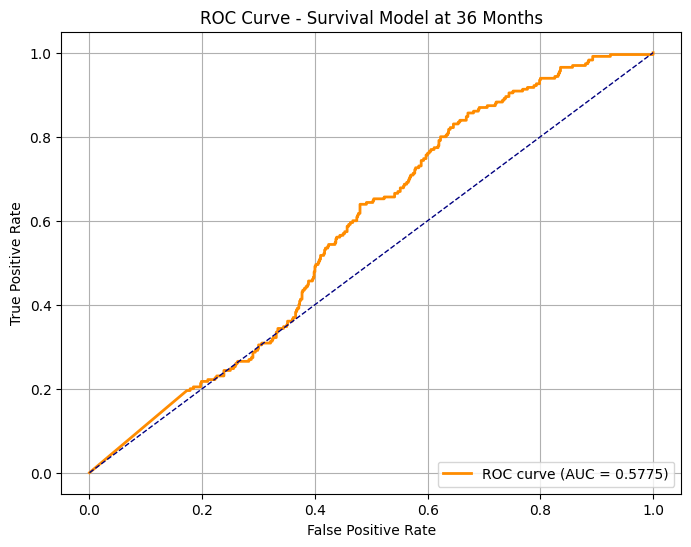

In [96]:
# AUC-ROC 
y_true1 = tied_exits_df['Event']
roc_auc = roc_auc_score(y_true1,y_pred)
fpr, tpr, thresholds = roc_curve(y_true1, y_pred)
print(f"ROC-AUC at 36 months: {roc_auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Survival Model at 36 Months")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
Stepped ROC curve is usual with Survival probabilities since the data for curve is low(2000) rows 

In [97]:
# Brier Score
# Convert survival prob to event prob (i.e., recovery)
event_probs = 1 - df['Surviva_prob_60']
actual_events = df['Event']  # 1 if recovered, 0 if censored

# Brier Score
brier = brier_score_loss(actual_events, event_probs)
print(f"Brier Score: {brier:.4f}")

Brier Score: 0.1128


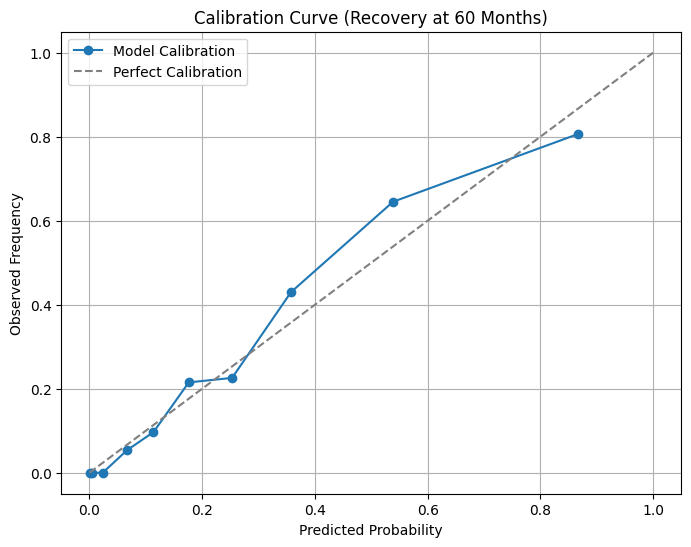

In [98]:
# Calibration PLot 
y_pred = df['pred_survival']
y_true = df['Event']

# Calibration curve
prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=10, strategy='quantile')

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o', label='Model Calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve (Recovery at 60 Months)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Hosmer Lemeshow statistic - for Logistic Regression 
import numpy as np
import pandas as pd
from scipy.stats import chi2

# Your predicted probabilities and actual binary outcomes
y_pred = 1 - df['Surviva_prob_60']   # predicted probability of recovery
y_true = df['Event']                # actual recovery indicator (1 = recovered, 0 = not)

# Combine into a dataframe
data = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})

# Create 10 risk deciles
data['decile'] = pd.qcut(data['y_pred'], 10, labels=False)

# Group by decile
grouped = data.groupby('decile')
observed = grouped['y_true'].sum()                     # actual recoveries
expected = grouped['y_pred'].sum()                     # predicted recoveries
n = grouped['y_true'].count()                          # number of samples per group

# Calculate Hosmer–Lemeshow statistic
hl_stat = np.sum(((observed - expected) ** 2) / (expected * (1 - expected / n)))
df_hl = 8  # degrees of freedom = number of groups - 2
p_value = 1 - chi2.cdf(hl_stat, df_hl)

print(f"Hosmer–Lemeshow Statistic: {hl_stat:.4f}")
print(f"P-value: {p_value:.4f}")